# Clasificación de riesgo cardiaco con regresión logística

Este cuaderno reproduce en Python el flujo construido en **Orange Data Mining**:

1. Cargar el dataset cardiaco.
2. Explorar sus 13 variables predictoras.
3. Separar **70 % entrenamiento** y **30 % prueba**.
4. Preprocesar variables numéricas y categóricas.
5. Entrenar una **regresión logística**.
6. Predecir el riesgo en el conjunto de prueba.
7. Calcular **accuracy, AUC, F1, precision y recall**.
8. Visualizar la **matriz de confusión** y la **curva ROC**.
9. Examinar predicciones y coeficientes.

> **Advertencia clínica:** el target fue renombrado didácticamente como `Riesgo_Ataque_Cardiaco`. El dataset original representa presencia o ausencia de enfermedad cardiaca; este cuaderno no es una herramienta diagnóstica ni de pronóstico de infarto.

## 1. Importar bibliotecas

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)
RANDOM_STATE = 42

## 2. Cargar el dataset

In [2]:
def localizar_archivo(nombre):
    candidatos = [Path(nombre), Path("/mnt/data") / nombre]
    for ruta in candidatos:
        if ruta.exists():
            return ruta
    raise FileNotFoundError(
        f"No se encontró {nombre}. Colóquelo en la misma carpeta del cuaderno."
    )

RUTA_DATOS = localizar_archivo("riesgo_ataque_cardiaco_uci_orange.csv")
df = pd.read_csv(RUTA_DATOS)

print(f"Archivo: {RUTA_DATOS}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
display(df.head())

Archivo: riesgo_ataque_cardiaco_uci_orange.csv
Filas: 303
Columnas: 15


,ID,Edad,Sexo,Tipo_Dolor_Pecho,Presion_Reposo,Colesterol,Glucosa_Ayunas_Alta,ECG_Reposo,Frecuencia_Cardiaca_Max,Angina_Ejercicio,Depresion_ST,Pendiente_ST,Vasos_Principales,Talasemia,Riesgo_Ataque_Cardiaco
0,1,63,Masculino,Tipo_3,145,233,Si,Resultado_0,150,No,2.3,Tipo_0,0,Categoria_1,Alto
1,2,37,Masculino,Tipo_2,130,250,No,Resultado_1,187,No,3.5,Tipo_0,0,Categoria_2,Alto
2,3,41,Femenino,Tipo_1,130,204,No,Resultado_0,172,No,1.4,Tipo_2,0,Categoria_2,Alto
3,4,56,Masculino,Tipo_1,120,236,No,Resultado_1,178,No,0.8,Tipo_2,0,Categoria_2,Alto
4,5,57,Femenino,Tipo_0,120,354,No,Resultado_1,163,Si,0.6,Tipo_2,0,Categoria_2,Alto


## 3. Exploración inicial

In [3]:
resumen = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "Valores_faltantes": df.isna().sum(),
    "Valores_unicos": df.nunique(),
})
display(resumen)

print("\nDistribución del target:")
display(
    df["Riesgo_Ataque_Cardiaco"]
    .value_counts()
    .rename_axis("Clase")
    .to_frame("Cantidad")
    .assign(Porcentaje=lambda x: (100 * x["Cantidad"] / len(df)).round(2))
)

,Tipo,Valores_faltantes,Valores_unicos
ID,int64,0,303
Edad,int64,0,41
Sexo,object,0,2
Tipo_Dolor_Pecho,object,0,4
Presion_Reposo,int64,0,49
Colesterol,int64,0,152
Glucosa_Ayunas_Alta,object,0,2
ECG_Reposo,object,0,3
Frecuencia_Cardiaca_Max,int64,0,91
Angina_Ejercicio,object,0,2



Distribución del target:


,Cantidad,Porcentaje
Clase,,
Alto,165,54.46
Bajo,138,45.54


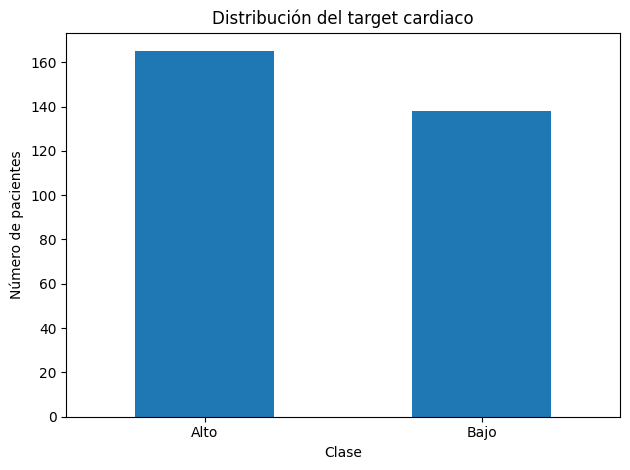

In [4]:
df["Riesgo_Ataque_Cardiaco"].value_counts().plot(kind="bar")
plt.title("Distribución del target cardiaco")
plt.xlabel("Clase")
plt.ylabel("Número de pacientes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Definir features y target

- **Target:** `Riesgo_Ataque_Cardiaco`
- **Clase positiva:** `Alto`
- `ID` se elimina porque es únicamente un identificador.

In [5]:
TARGET = "Riesgo_Ataque_Cardiaco"
CLASE_POSITIVA = "Alto"

X = df.drop(columns=["ID", TARGET])
y = df[TARGET]

columnas_numericas = X.select_dtypes(include=np.number).columns.tolist()
columnas_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:")
print(columnas_numericas)
print("\nVariables categóricas:")
print(columnas_categoricas)
print(f"\nNúmero total de features originales: {X.shape[1]}")

Variables numéricas:
['Edad', 'Presion_Reposo', 'Colesterol', 'Frecuencia_Cardiaca_Max', 'Depresion_ST', 'Vasos_Principales']

Variables categóricas:
['Sexo', 'Tipo_Dolor_Pecho', 'Glucosa_Ayunas_Alta', 'ECG_Reposo', 'Angina_Ejercicio', 'Pendiente_ST', 'Talasemia']

Número total de features originales: 13


## 5. Separar entrenamiento y prueba

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Entrenamiento: {len(X_train)} pacientes ({len(X_train)/len(X):.1%})")
print(f"Prueba:        {len(X_test)} pacientes ({len(X_test)/len(X):.1%})")

comparacion = pd.concat(
    [
        y_train.value_counts(normalize=True).rename("Entrenamiento"),
        y_test.value_counts(normalize=True).rename("Prueba"),
    ],
    axis=1,
).mul(100).round(2)

display(comparacion)

Entrenamiento: 212 pacientes (70.0%)
Prueba:        91 pacientes (30.0%)


,Entrenamiento,Prueba
Riesgo_Ataque_Cardiaco,,
Alto,54.25,54.95
Bajo,45.75,45.05


## 6. Preprocesamiento y regresión logística

El pipeline:

- Imputa faltantes numéricos con la mediana.
- Estandariza las variables numéricas.
- Imputa categorías faltantes con la moda.
- Codifica categorías con *one-hot encoding*.
- Entrena una regresión logística con regularización L2.

In [7]:
preprocesador_numerico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler()),
    ]
)

preprocesador_categorico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        ("numericas", preprocesador_numerico, columnas_numericas),
        ("categoricas", preprocesador_categorico, columnas_categoricas),
    ]
)

modelo = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "regresion_logistica",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                max_iter=5000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('regresion_logistica', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

## 7. Entrenar el modelo

In [8]:
modelo.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 8. Predicciones sobre el 30 % de prueba

In [9]:
y_pred = modelo.predict(X_test)
clases_modelo = modelo.named_steps["regresion_logistica"].classes_
indice_positivo = list(clases_modelo).index(CLASE_POSITIVA)
y_prob = modelo.predict_proba(X_test)[:, indice_positivo]

predicciones = X_test.copy()
predicciones["Riesgo_real"] = y_test
predicciones["Riesgo_predicho"] = y_pred
predicciones["Probabilidad_Riesgo_Alto"] = y_prob
predicciones["Prediccion_correcta"] = (
    predicciones["Riesgo_real"] == predicciones["Riesgo_predicho"]
)

predicciones = predicciones.sort_values(
    "Probabilidad_Riesgo_Alto", ascending=False
)

display(predicciones.head(15))

,Edad,Sexo,Tipo_Dolor_Pecho,Presion_Reposo,Colesterol,Glucosa_Ayunas_Alta,ECG_Reposo,Frecuencia_Cardiaca_Max,Angina_Ejercicio,Depresion_ST,Pendiente_ST,Vasos_Principales,Talasemia,Riesgo_real,Riesgo_predicho,Probabilidad_Riesgo_Alto,Prediccion_correcta
74,43,Femenino,Tipo_2,122,213,No,Resultado_1,165,No,0.2,Tipo_1,0,Categoria_2,Alto,Alto,0.983520,True
130,54,Femenino,Tipo_2,160,201,No,Resultado_1,163,No,0.0,Tipo_2,1,Categoria_2,Alto,Alto,0.978937,True
136,60,Femenino,Tipo_2,120,178,Si,Resultado_1,96,No,0.0,Tipo_2,0,Categoria_2,Alto,Alto,0.978870,True
54,63,Femenino,Tipo_2,135,252,No,Resultado_0,172,No,0.0,Tipo_2,0,Categoria_2,Alto,Alto,0.978466,True
50,51,Femenino,Tipo_2,130,256,No,Resultado_0,149,No,0.5,Tipo_2,0,Categoria_2,Alto,Alto,0.975438,True
147,60,Femenino,Tipo_3,150,240,No,Resultado_1,171,No,0.9,Tipo_2,0,Categoria_2,Alto,Alto,0.975383,True
140,51,Femenino,Tipo_2,120,295,No,Resultado_0,157,No,0.6,Tipo_2,0,Categoria_2,Alto,Alto,0.973643,True
162,41,Masculino,Tipo_1,120,157,No,Resultado_1,182,No,0.0,Tipo_2,0,Categoria_2,Alto,Alto,0.971343,True
149,42,Masculino,Tipo_2,130,180,No,Resultado_1,150,No,0.0,Tipo_2,0,Categoria_2,Alto,Alto,0.970965,True
148,44,Masculino,Tipo_2,120,226,No,Resultado_1,169,No,0.0,Tipo_2,0,Categoria_2,Alto,Alto,0.970636,True


## 9. Accuracy y métricas

In [10]:
y_test_binario = (y_test == CLASE_POSITIVA).astype(int)
y_pred_binario = (y_pred == CLASE_POSITIVA).astype(int)

metricas = pd.DataFrame(
    {
        "Métrica": ["Accuracy", "AUC", "F1", "Precision", "Recall"],
        "Valor": [
            accuracy_score(y_test, y_pred),
            roc_auc_score(y_test_binario, y_prob),
            f1_score(y_test_binario, y_pred_binario),
            precision_score(y_test_binario, y_pred_binario),
            recall_score(y_test_binario, y_pred_binario),
        ],
    }
)
metricas["Valor"] = metricas["Valor"].round(4)
display(metricas)

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, digits=4))

,Métrica,Valor
0,Accuracy,0.8242
1,AUC,0.8980
2,F1,0.8491
3,Precision,0.8036
4,Recall,0.9000


Reporte de clasificación:
              precision    recall  f1-score   support

        Alto     0.8036    0.9000    0.8491        50
        Bajo     0.8571    0.7317    0.7895        41

    accuracy                         0.8242        91
   macro avg     0.8304    0.8159    0.8193        91
weighted avg     0.8277    0.8242    0.8222        91



## 10. Matriz de confusión

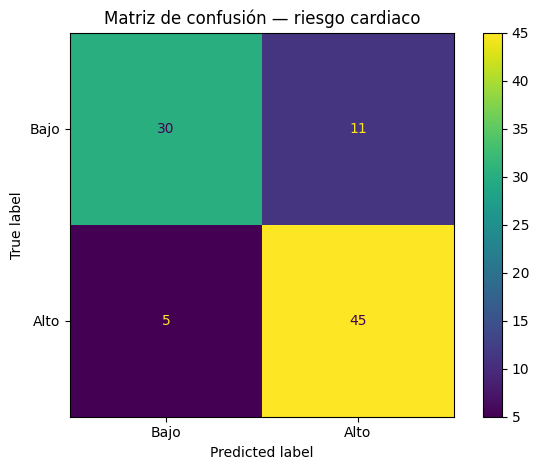

,Predicho_Bajo,Predicho_Alto
Real_Bajo,30,11
Real_Alto,5,45


In [11]:
orden_clases = ["Bajo", "Alto"]
matriz = confusion_matrix(y_test, y_pred, labels=orden_clases)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=orden_clases,
)
disp.plot(values_format="d")
plt.title("Matriz de confusión — riesgo cardiaco")
plt.tight_layout()
plt.show()

pd.DataFrame(
    matriz,
    index=[f"Real_{c}" for c in orden_clases],
    columns=[f"Predicho_{c}" for c in orden_clases],
)

## 11. Curva ROC

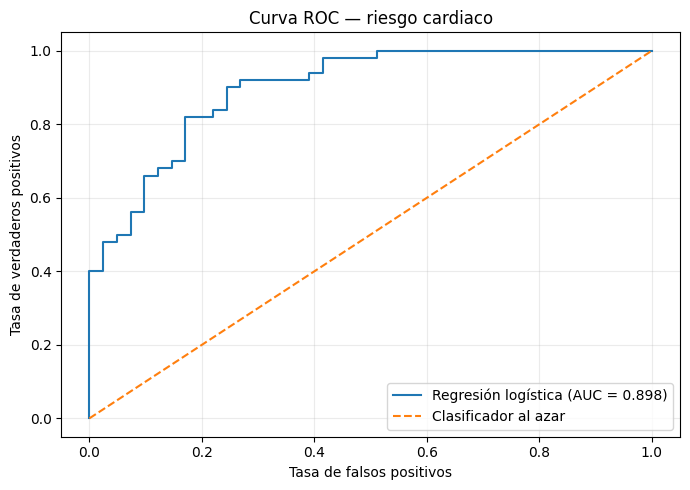

In [12]:
fpr, tpr, umbrales = roc_curve(y_test_binario, y_prob)
auc = roc_auc_score(y_test_binario, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Regresión logística (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador al azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC — riesgo cardiaco")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 12. Revisar falsos positivos y falsos negativos

In [13]:
errores = predicciones.loc[~predicciones["Prediccion_correcta"]]

falsos_positivos = errores.loc[
    (errores["Riesgo_real"] == "Bajo")
    & (errores["Riesgo_predicho"] == "Alto")
]

falsos_negativos = errores.loc[
    (errores["Riesgo_real"] == "Alto")
    & (errores["Riesgo_predicho"] == "Bajo")
]

print(f"Errores totales: {len(errores)}")
print(f"Falsos positivos: {len(falsos_positivos)}")
print(f"Falsos negativos: {len(falsos_negativos)}")

print("\nFalsos negativos:")
display(falsos_negativos.head(20))

print("\nFalsos positivos:")
display(falsos_positivos.head(20))

Errores totales: 16
Falsos positivos: 11
Falsos negativos: 5

Falsos negativos:


,Edad,Sexo,Tipo_Dolor_Pecho,Presion_Reposo,Colesterol,Glucosa_Ayunas_Alta,ECG_Reposo,Frecuencia_Cardiaca_Max,Angina_Ejercicio,Depresion_ST,Pendiente_ST,Vasos_Principales,Talasemia,Riesgo_real,Riesgo_predicho,Probabilidad_Riesgo_Alto,Prediccion_correcta
83,52,Masculino,Tipo_3,152,298,Si,Resultado_1,178,No,1.2,Tipo_1,0,Categoria_3,Alto,Bajo,0.499918,False
91,57,Masculino,Tipo_0,132,207,No,Resultado_1,168,Si,0.0,Tipo_2,0,Categoria_3,Alto,Bajo,0.305127,False
20,59,Masculino,Tipo_0,135,234,No,Resultado_1,161,No,0.5,Tipo_1,0,Categoria_3,Alto,Bajo,0.287936,False
150,66,Masculino,Tipo_0,160,228,No,Resultado_0,138,No,2.3,Tipo_2,0,Categoria_1,Alto,Bajo,0.281639,False
52,62,Masculino,Tipo_2,130,231,No,Resultado_1,146,No,1.8,Tipo_1,3,Categoria_3,Alto,Bajo,0.188982,False



Falsos positivos:


,Edad,Sexo,Tipo_Dolor_Pecho,Presion_Reposo,Colesterol,Glucosa_Ayunas_Alta,ECG_Reposo,Frecuencia_Cardiaca_Max,Angina_Ejercicio,Depresion_ST,Pendiente_ST,Vasos_Principales,Talasemia,Riesgo_real,Riesgo_predicho,Probabilidad_Riesgo_Alto,Prediccion_correcta
302,57,Femenino,Tipo_1,130,236,No,Resultado_0,174,No,0.0,Tipo_1,1,Categoria_2,Bajo,Alto,0.918294,False
287,57,Masculino,Tipo_1,154,232,No,Resultado_0,164,No,0.0,Tipo_2,1,Categoria_2,Bajo,Alto,0.832433,False
286,59,Masculino,Tipo_3,134,204,No,Resultado_1,162,No,0.8,Tipo_2,2,Categoria_2,Bajo,Alto,0.815192,False
196,46,Masculino,Tipo_2,150,231,No,Resultado_1,147,No,3.6,Tipo_1,0,Categoria_2,Bajo,Alto,0.795732,False
194,60,Masculino,Tipo_2,140,185,No,Resultado_0,155,No,3.0,Tipo_1,0,Categoria_2,Bajo,Alto,0.763678,False
261,52,Masculino,Tipo_0,112,230,No,Resultado_1,160,No,0.0,Tipo_2,1,Categoria_2,Bajo,Alto,0.731476,False
267,49,Masculino,Tipo_2,118,149,No,Resultado_0,126,No,0.8,Tipo_2,3,Categoria_2,Bajo,Alto,0.721421,False
241,59,Femenino,Tipo_0,174,249,No,Resultado_1,143,Si,0.0,Tipo_1,0,Categoria_2,Bajo,Alto,0.656025,False
216,62,Femenino,Tipo_2,130,263,No,Resultado_1,97,No,1.2,Tipo_1,1,Categoria_3,Bajo,Alto,0.642733,False
188,50,Masculino,Tipo_2,140,233,No,Resultado_1,163,No,0.6,Tipo_1,1,Categoria_3,Bajo,Alto,0.590503,False


## 13. Interpretar los coeficientes

- Coeficiente positivo: asociación con mayor probabilidad estimada de clase `Alto`.
- Coeficiente negativo: asociación con menor probabilidad estimada de clase `Alto`.
- La magnitud muestra la fuerza de asociación dentro del modelo.

Los coeficientes no prueban causalidad ni sustituyen la interpretación médica.

In [14]:
nombres_features = (
    modelo.named_steps["preprocesamiento"].get_feature_names_out()
)
coeficientes = modelo.named_steps["regresion_logistica"].coef_[indice_positivo]

tabla_coeficientes = pd.DataFrame(
    {
        "Feature_transformada": nombres_features,
        "Coeficiente": coeficientes,
    }
)
tabla_coeficientes["Magnitud"] = tabla_coeficientes["Coeficiente"].abs()

print("Asociaciones positivas más fuertes con Riesgo Alto:")
display(
    tabla_coeficientes
    .sort_values("Coeficiente", ascending=False)
    .head(15)
)

print("Asociaciones negativas más fuertes con Riesgo Alto:")
display(
    tabla_coeficientes
    .sort_values("Coeficiente", ascending=True)
    .head(15)
)

Asociaciones positivas más fuertes con Riesgo Alto:


,Feature_transformada,Coeficiente,Magnitud
8,categoricas__Tipo_Dolor_Pecho_Tipo_0,1.115204,1.115204
25,categoricas__Talasemia_Categoria_3,0.681966,0.681966
7,categoricas__Sexo_Masculino,0.619008,0.619008
5,numericas__Vasos_Principales,0.559173,0.559173
18,categoricas__Angina_Ejercicio_Si,0.451871,0.451871
4,numericas__Depresion_ST,0.367948,0.367948
20,categoricas__Pendiente_ST_Tipo_1,0.360098,0.360098
2,numericas__Colesterol,0.222362,0.222362
22,categoricas__Talasemia_Categoria_0,0.196434,0.196434
14,categoricas__ECG_Reposo_Resultado_0,0.155681,0.155681


Asociaciones negativas más fuertes con Riesgo Alto:


,Feature_transformada,Coeficiente,Magnitud
24,categoricas__Talasemia_Categoria_2,-0.786759,0.786759
6,categoricas__Sexo_Femenino,-0.622283,0.622283
10,categoricas__Tipo_Dolor_Pecho_Tipo_2,-0.614661,0.614661
17,categoricas__Angina_Ejercicio_No,-0.455146,0.455146
11,categoricas__Tipo_Dolor_Pecho_Tipo_3,-0.305291,0.305291
15,categoricas__ECG_Reposo_Resultado_1,-0.283926,0.283926
21,categoricas__Pendiente_ST_Tipo_2,-0.253843,0.253843
9,categoricas__Tipo_Dolor_Pecho_Tipo_1,-0.198528,0.198528
3,numericas__Frecuencia_Cardiaca_Max,-0.177517,0.177517
19,categoricas__Pendiente_ST_Tipo_0,-0.109530,0.109530


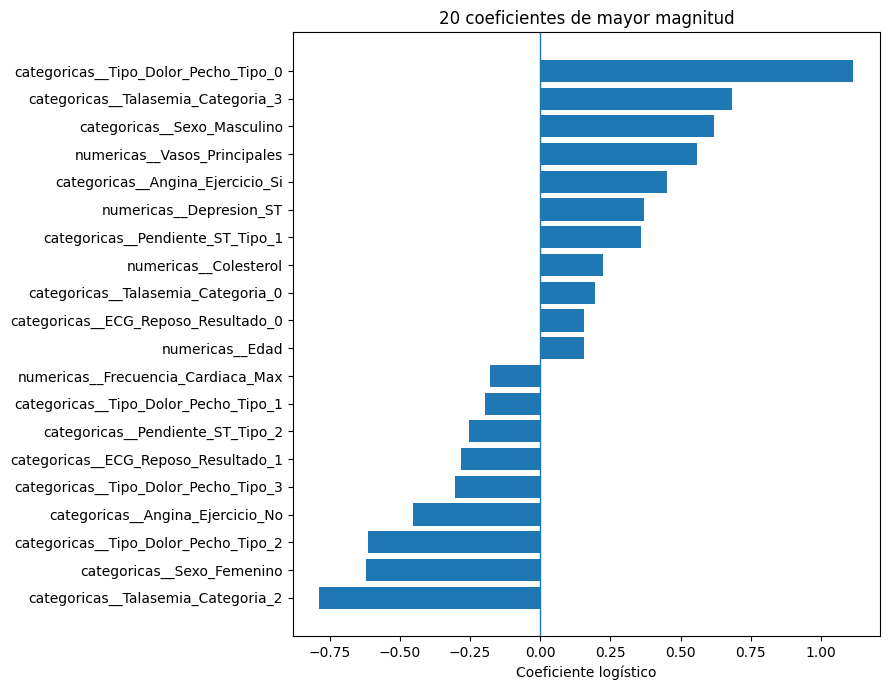

In [15]:
top_coef = (
    tabla_coeficientes
    .nlargest(20, "Magnitud")
    .sort_values("Coeficiente")
)

plt.figure(figsize=(9, 7))
plt.barh(top_coef["Feature_transformada"], top_coef["Coeficiente"])
plt.axvline(0, linewidth=1)
plt.title("20 coeficientes de mayor magnitud")
plt.xlabel("Coeficiente logístico")
plt.tight_layout()
plt.show()

## 14. Guardar las predicciones

In [16]:
SALIDA = Path("predicciones_riesgo_cardiaco_regresion_logistica.csv")
predicciones.to_csv(SALIDA, index=False, encoding="utf-8-sig")
print(f"Predicciones guardadas en: {SALIDA.resolve()}")

Predicciones guardadas en: /mnt/data/predicciones_riesgo_cardiaco_regresion_logistica.csv


## Conclusión

El cuaderno usa un conjunto de prueba independiente para estimar el desempeño del modelo:

- **Accuracy:** proporción total de pacientes bien clasificados.
- **Precision:** entre los clasificados como riesgo alto, cuántos pertenecían realmente a esa clase.
- **Recall:** entre los casos reales de riesgo alto, cuántos fueron detectados.
- **F1:** equilibrio entre precision y recall.
- **AUC:** discriminación del modelo a través de múltiples umbrales.

En un contexto clínico, los falsos negativos suelen merecer atención especial, pero cualquier decisión médica exige validación clínica, poblacional y prospectiva.